In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


Matplotlib created a temporary cache directory at /var/folders/nm/yz2z8w796mz79tfcqshfwxtr0000gr/T/matplotlib-c7jnabr2 because the default path (/Users/pujakadayat/.matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
df=pd.read_csv("risk_factors_cervical_cancer.csv")

In [3]:
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [4]:
cols = df.columns

In [5]:
cols = ["Age","Smokes","Smokes (years)","Smokes (packs/year)","Hormonal Contraceptives","STDs:HIV","STDs:HPV","Number of sexual partners","First sexual intercourse",'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy']

In [6]:
df = df[cols]

In [7]:
df.head(5)

,Age,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,STDs:HIV,STDs:HPV,Number of sexual partners,First sexual intercourse,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,0.0,0.0,0.0,0.0,0.0,0.0,4.0,15.0,0,0,0,0,0,0,0,0
1,15,0.0,0.0,0.0,0.0,0.0,0.0,1.0,14.0,0,0,0,0,0,0,0,0
2,34,0.0,0.0,0.0,0.0,0.0,0.0,1.0,?,0,0,0,0,0,0,0,0
3,52,1.0,37.0,37.0,1.0,0.0,0.0,5.0,16.0,1,0,1,0,0,0,0,0
4,46,0.0,0.0,0.0,1.0,0.0,0.0,3.0,21.0,0,0,0,0,0,0,0,0


In [8]:
df.tail()

,Age,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,STDs:HIV,STDs:HPV,Number of sexual partners,First sexual intercourse,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
853,34,0.0,0.0,0.0,0.0,0.0,0.0,3.0,18.0,0,0,0,0,0,0,0,0
854,32,0.0,0.0,0.0,1.0,0.0,0.0,2.0,19.0,0,0,0,0,0,0,0,0
855,25,0.0,0.0,0.0,1.0,0.0,0.0,2.0,17.0,0,0,0,0,0,0,1,0
856,33,0.0,0.0,0.0,1.0,0.0,0.0,2.0,24.0,0,0,0,0,0,0,0,0
857,29,0.0,0.0,0.0,1.0,0.0,0.0,2.0,20.0,0,0,0,0,0,0,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        858 non-null    int64 
 1   Smokes                     858 non-null    object
 2   Smokes (years)             858 non-null    object
 3   Smokes (packs/year)        858 non-null    object
 4   Hormonal Contraceptives    858 non-null    object
 5   STDs:HIV                   858 non-null    object
 6   STDs:HPV                   858 non-null    object
 7   Number of sexual partners  858 non-null    object
 8   First sexual intercourse   858 non-null    object
 9   Dx:Cancer                  858 non-null    int64 
 10  Dx:CIN                     858 non-null    int64 
 11  Dx:HPV                     858 non-null    int64 
 12  Dx                         858 non-null    int64 
 13  Hinselmann                 858 non-null    int64 
 14  Schiller  

In [10]:
df['Smokes'] = pd.to_numeric(df['Smokes'],errors="coerce")


In [11]:
for i in cols:
    df[i] = pd.to_numeric(df[i], errors="coerce")


In [16]:


binary_cols = ["Hormonal Contraceptives", "STDs:HIV", "STDs:HPV", "IUD", "STDs",
               "STDs:condylomatosis", "STDs:cervical condylomatosis",
               "STDs:vaginal condylomatosis", "STDs:vulvo-perineal condylomatosis",
               "STDs:syphilis", "STDs:pelvic inflammatory disease",
               "STDs:genital herpes", "STDs:molluscum contagiosum",
               "STDs:AIDS", "STDs:Hepatitis B"]

continuous_cols = ["Smokes (years)", "Smokes (packs/year)", "Number of sexual partners",
                    "First sexual intercourse", "Num of pregnancies",
                    "Hormonal Contraceptives (years)", "IUD (years)",
                    "STDs (number)", "STDs: Number of diagnosis"]

for c in binary_cols:
    df[c] = pd.to_numeric(df[i], errors="coerce")
    df[c] = df[c].fillna(df[c].mode()[0])

for c in continuous_cols:
    df[c] = pd.to_numeric(df[i], errors="coerce")
    df[c] = df[c].fillna(df[c].mean())

In [17]:
df["Smokes"] = df["Smokes"].fillna(df["Smokes"].mode()[0])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Smokes                              858 non-null    float64
 2   Smokes (years)                      858 non-null    int64  
 3   Smokes (packs/year)                 858 non-null    int64  
 4   Hormonal Contraceptives             858 non-null    int64  
 5   STDs:HIV                            858 non-null    int64  
 6   STDs:HPV                            858 non-null    int64  
 7   Number of sexual partners           858 non-null    int64  
 8   First sexual intercourse            858 non-null    int64  
 9   Dx:Cancer                           858 non-null    int64  
 10  Dx:CIN                              858 non-null    int64  
 11  Dx:HPV                              858 non-n

In [20]:
df.describe()

,Age,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,STDs:HIV,STDs:HPV,Number of sexual partners,First sexual intercourse,Dx:Cancer,...,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:Hepatitis B,Num of pregnancies,Hormonal Contraceptives (years),IUD (years),STDs (number),STDs: Number of diagnosis
count,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,...,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,0.143357,0.064103,0.064103,0.064103,0.064103,0.064103,0.064103,0.064103,0.020979,...,0.064103,0.064103,0.064103,0.064103,0.064103,0.064103,0.064103,0.064103,0.064103,0.064103
std,8.497948,0.350641,0.245078,0.245078,0.245078,0.245078,0.245078,0.245078,0.245078,0.143398,...,0.245078,0.245078,0.245078,0.245078,0.245078,0.245078,0.245078,0.245078,0.245078,0.245078
min,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
df.isnull().sum()

Age                                   0
Smokes                                0
Smokes (years)                        0
Smokes (packs/year)                   0
Hormonal Contraceptives               0
STDs:HIV                              0
STDs:HPV                              0
Number of sexual partners             0
First sexual intercourse              0
Dx:Cancer                             0
Dx:CIN                                0
Dx:HPV                                0
Dx                                    0
Hinselmann                            0
Schiller                              0
Citology                              0
Biopsy                                0
IUD                                   0
STDs                                  0
STDs:condylomatosis                   0
STDs:cervical condylomatosis          0
STDs:vaginal condylomatosis           0
STDs:vulvo-perineal condylomatosis    0
STDs:syphilis                         0
STDs:pelvic inflammatory disease      0


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 1200x400 with 0 Axes>

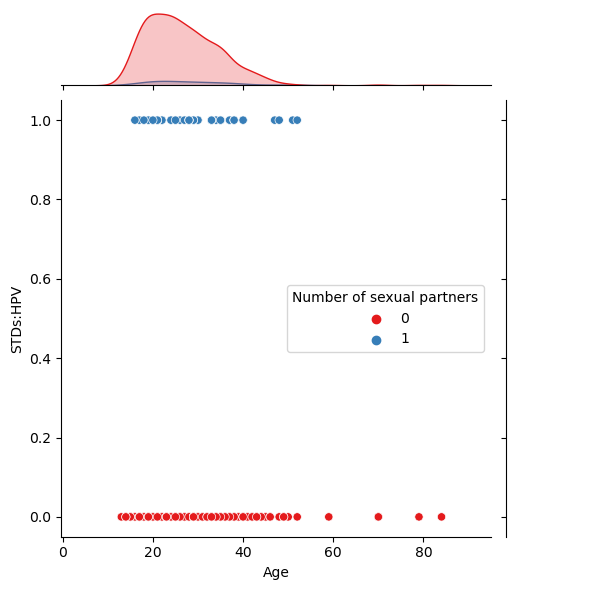

In [23]:

plt.figure(figsize=(12,4))
df["Partners_group"] = pd.cut(df['Number of sexual partners'], bins = [0,1,3,5,100],labels = ["1","2-3","4-5","6+"])
sns.jointplot(data=df,x="Age",y="STDs:HPV", hue="Number of sexual partners",palette = "Set1")
plt.show()

Biopsy Result Distribution

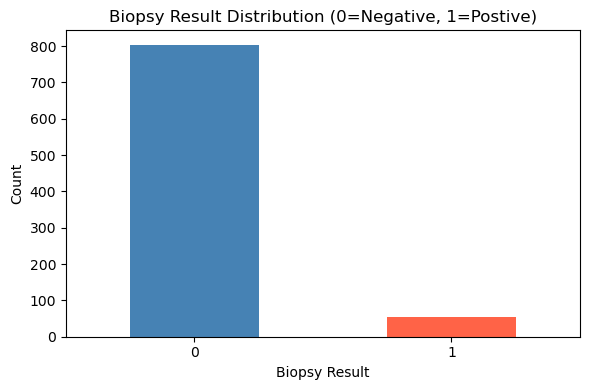

Class imbalance ratio: 14.6:1


In [25]:
plt.figure(figsize= (6,4))
df['Biopsy'].value_counts().plot(kind="bar",color= ['steelblue','tomato'])
plt.title('Biopsy Result Distribution (0=Negative, 1=Postive)')
plt.xlabel('Biopsy Result')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()
print(f"Class imbalance ratio: {df['Biopsy'].value_counts()[0]/df['Biopsy'].value_counts()[1]:.1f}:1")


Age distribution by Cance diagnosis

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


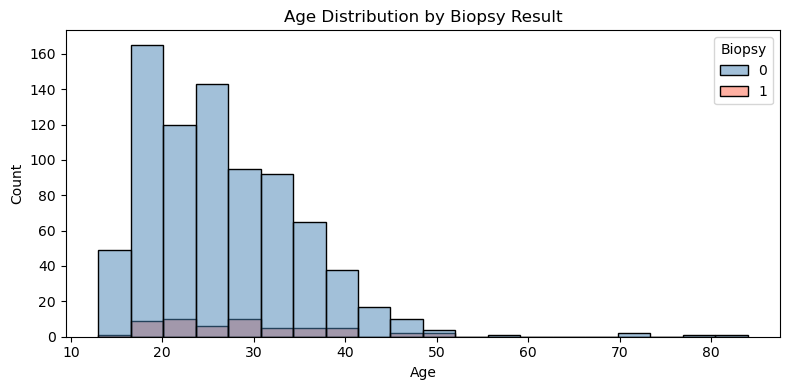

In [26]:
plt.figure(figsize=(8,4))
sns.histplot(data = df, x='Age', hue = "Biopsy", bins=20,palette=['steelblue','tomato'])
plt.title('Age Distribution by Biopsy Result')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

Features and labels


In [29]:
feature_cols = ['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis']
X = df[feature_cols]
y= df['Biopsy']
print(y.value_counts())


X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)


Biopsy
0    803
1     55
Name: count, dtype: int64


Feature Coorelation Heatmap- Cervical Cancer Risk Factors

/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


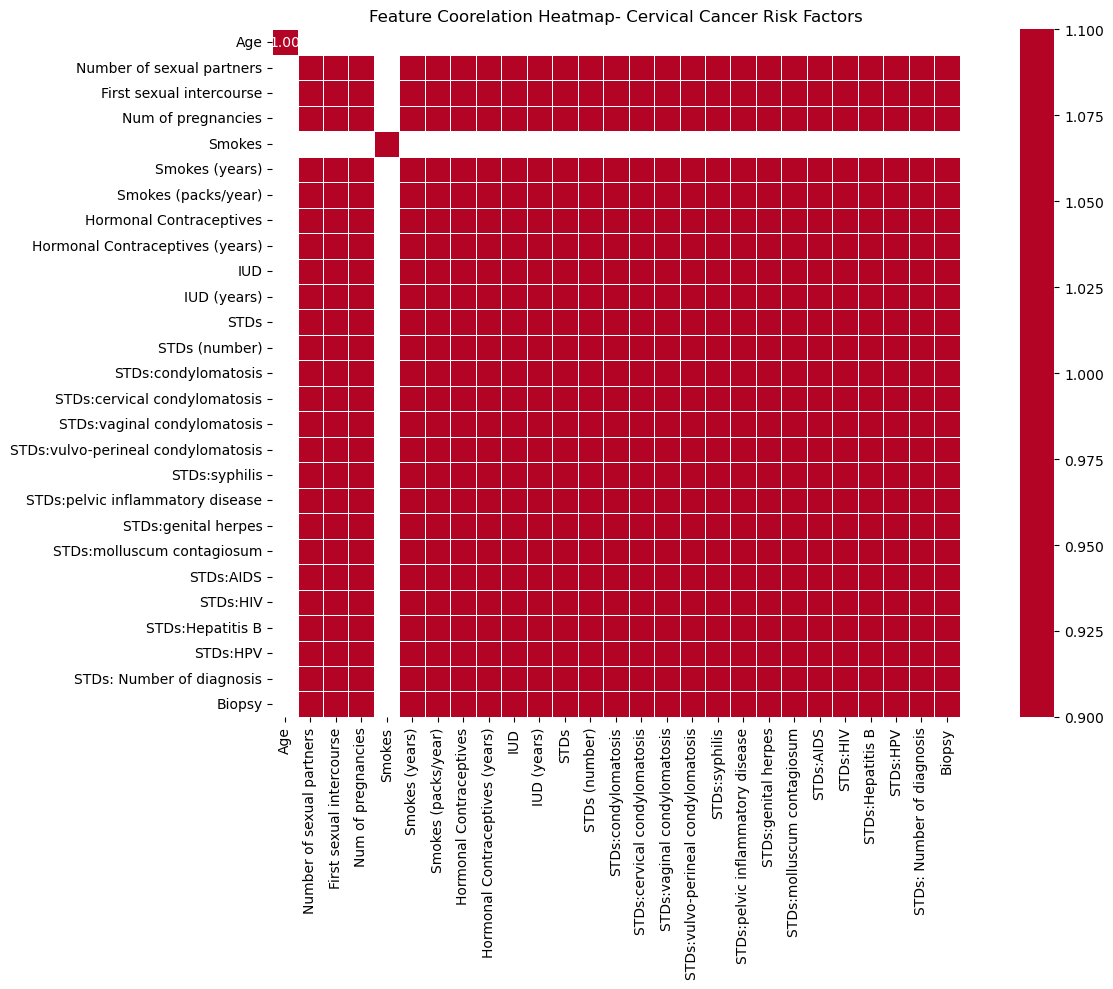

In [41]:
plt.figure(figsize = (14,10))
corr = df[feature_cols + ['Biopsy']].corr()
mask = corr.abs() < 0.1
sns.heatmap(corr,mask= mask, annot=True, fmt = ".2f",cmap = "coolwarm",center = 0, square = True,linewidth = 0.5)
plt.title('Feature Coorelation Heatmap- Cervical Cancer Risk Factors')
plt.tight_layout()
plt.show()

In [ ]:
X_train.isnull().sum()

Training logistic Regression Model

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix

scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_scaled,y_train)

y_prediction = model.predict(X_test_scaled)
print(classification_report(y_test,y_prediction))
print(confusion_matrix(y_test,y_prediction))

In [ ]:
from sklearn.metrics import roc_auc_score
y_prob = model.predict_proba(X_test_scaled)[:,1]
auc_prob = roc_auc_score(y_test,y_prob)
print(auc_prob)

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model,X_train_scaled,y_train,cv=5, scoring = "roc_auc")
print(scores)
print(scores.mean())

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring="roc_auc")
print(rf_scores)
print(rf_scores.mean())

In [ ]:
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.head(10))

In [ ]:
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

y_pred_rf_lower = (y_prob_rf >= 0.3).astype(int)
print("Threshold = 0.3")
print(classification_report(y_test, y_pred_rf_lower))
print(confusion_matrix(y_test, y_pred_rf_lower))